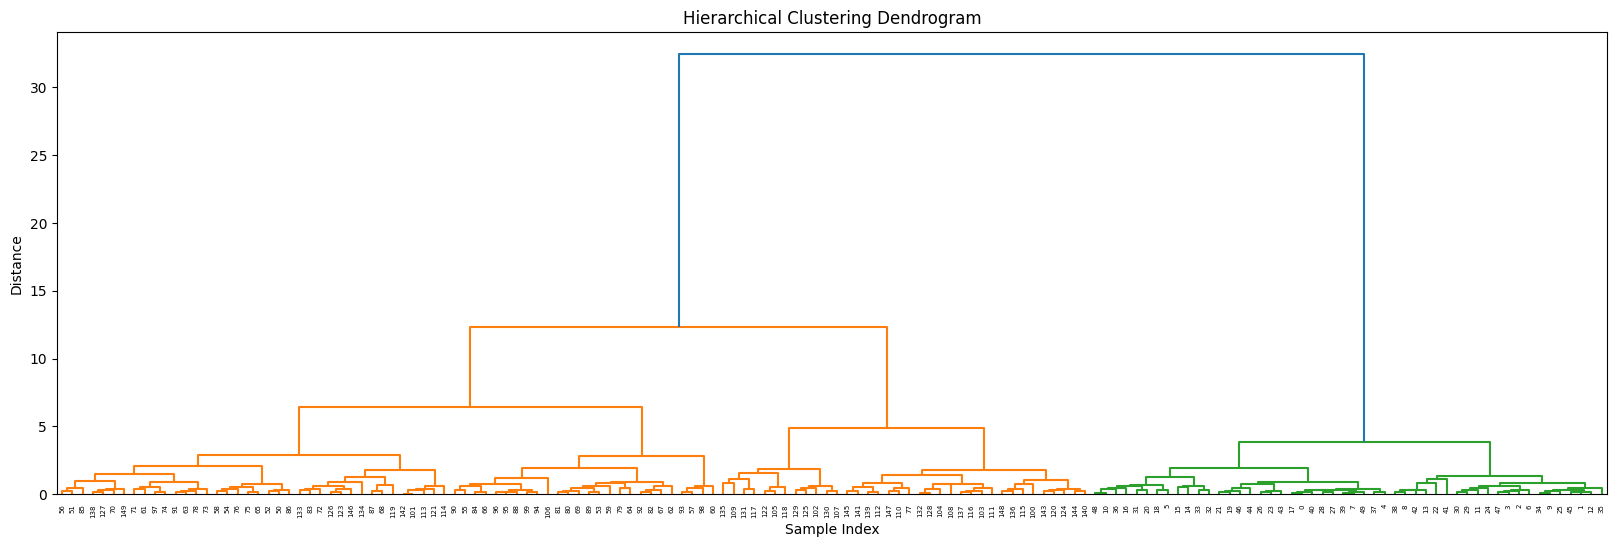

Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [5]:
# Hierarchical Clustering (Small Dataset)
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Load sample dataset (Iris)
data = load_iris()
X = data.data

# Fit Agglomerative Clustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X)

# Plot dendrogram
linked = linkage(X, method='ward')

plt.figure(figsize=(20, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Print cluster labels
print("Cluster labels:", labels)


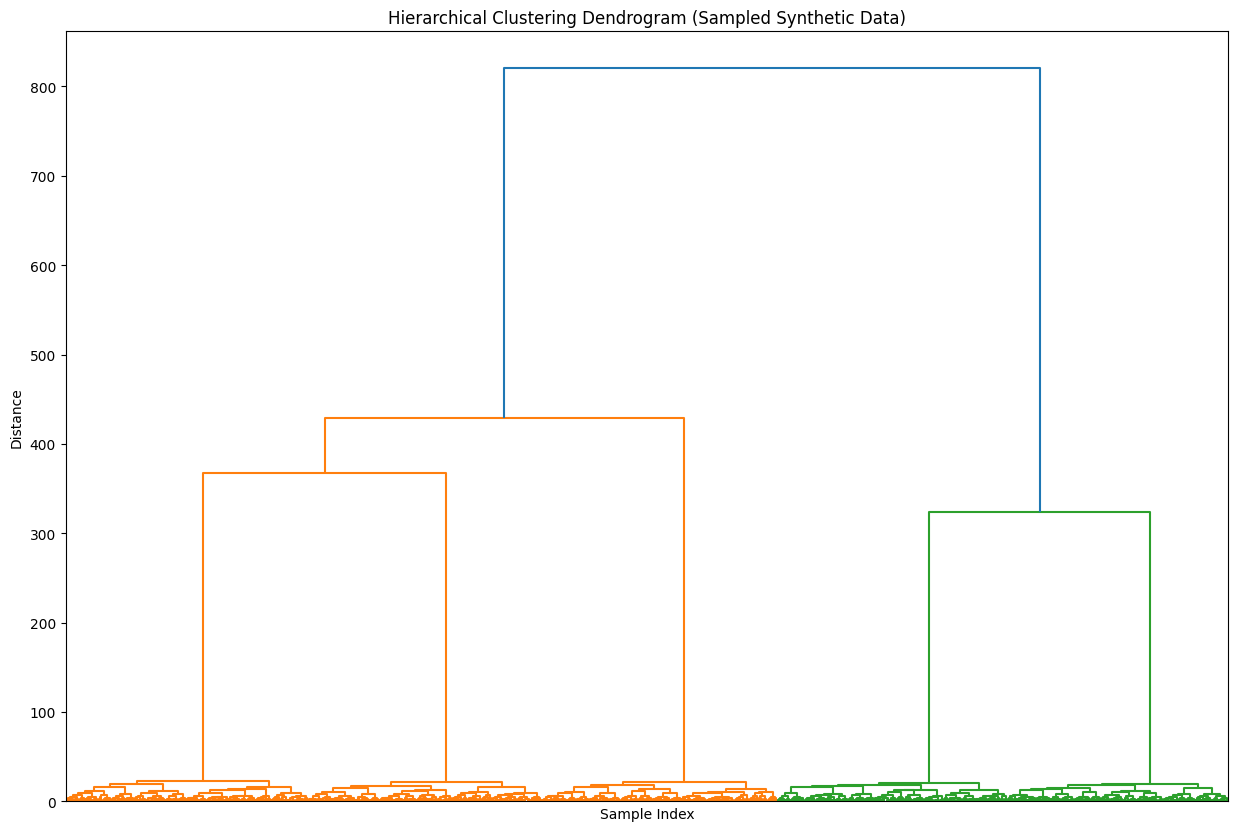

Cluster labels for sampled data: [2 0 1 2 1 2 0 4 2 2 4 4 4 1 0 2 2 3 3 1]
Cluster labels for full dataset (first 20): [1 0 4 4 3 0 2 4 1 1 0 1 4 4 3 2 1 3 4 1]


In [7]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate synthetic large dataset with 10,000 samples and 10 features
X, y_true = make_blobs(n_samples=10000, n_features=10, centers=5, cluster_std=1.0, random_state=42)

# Downsample for dendrogram plotting (max 2000 samples)
max_samples = 2000
if len(X) > max_samples:
    idx = np.random.choice(len(X), max_samples, replace=False)
    X_sample = X[idx]
else:
    X_sample = X

# Optional: reduce dimensions with PCA for faster linkage computation
pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_sample)

# Compute linkage matrix for dendrogram (Ward linkage)
linked = linkage(X_reduced, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           no_labels=True)
plt.title('Hierarchical Clustering Dendrogram (Sampled Synthetic Data)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Fit AgglomerativeClustering on sampled data
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_sample = agg.fit_predict(X_reduced)
print("Cluster labels for sampled data:", labels_sample[:20])

# Optional: fit on full dataset using PCA-reduced features
X_full_reduced = pca.transform(X)
agg_full = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_full = agg_full.fit_predict(X_full_reduced)
print("Cluster labels for full dataset (first 20):", labels_full[:20])
